In [ ]:
import torch
from train_utils import train_model, model_setup
from preprocess_utils import prepare_data, check_config
from plot_utils import plots
from copy import deepcopy as dc

In [ ]:
data_config = {"x_path": "data/friction_data/features_SlipLaw_v2.csv",
               "y_path": "data/friction_data/targets_SlipLaw_v2.csv",
               'train_samples': 700,
               'log_norm': False,
               'state_norm': True,
               'heal_norm': True}

# lift_config = {"NN" : False,
#                "act": "GELU"
#                }

lift_config = {"NN": True,
                 "NN_params": {"width": 64,
                               "depth": 2},
                 "act": "SiLU"
                 }

decode_config = {"NN": True,
                 "NN_params": {"width": 64,
                               "depth": 2},
                 "act": "SiLU"
                 }

fno_config = {"mode": 12,
              "blocks": 4,
              "act": "GELU",
              "width": 32,
              "padding": 8,
              "coord_features": False,
              "adaptive": False,
              }

train_config = {'lr': 1e-3,
                'decay': 0.995,
                'decay_steps': 1000,
                'save_results': True,
                'epochs': 300}

single_config = {'model_type': 'single',
          "train": train_config,
          "lift": lift_config,
          "fno": fno_config,
          "decode": decode_config,
          'data': data_config}

PREPARING DATA
	 USING STATE NORM DATA
	 USING HEAL NORM DATA
Total parameters: 116065
Beginning Training for 300
EPOCH 0: train_loss: 6.884e-02 	 test_loss: 2.026e-01
EPOCH 1: train_loss: 4.975e-02 	 test_loss: 3.468e-02
EPOCH 2: train_loss: 2.527e-02 	 test_loss: 2.202e-02
EPOCH 3: train_loss: 2.727e-02 	 test_loss: 1.604e-02
EPOCH 4: train_loss: 2.024e-02 	 test_loss: 1.306e-02
EPOCH 5: train_loss: 2.123e-02 	 test_loss: 1.285e-02
EPOCH 6: train_loss: 2.191e-02 	 test_loss: 1.177e-02
EPOCH 7: train_loss: 1.595e-02 	 test_loss: 1.061e-02
EPOCH 8: train_loss: 2.824e-02 	 test_loss: 1.157e-02
EPOCH 9: train_loss: 1.830e-02 	 test_loss: 9.981e-03
EPOCH 10: train_loss: 1.743e-02 	 test_loss: 9.961e-03
EPOCH 11: train_loss: 1.580e-02 	 test_loss: 8.766e-03
EPOCH 12: train_loss: 1.215e-02 	 test_loss: 8.067e-03
EPOCH 13: train_loss: 2.018e-02 	 test_loss: 8.246e-03
EPOCH 14: train_loss: 1.654e-02 	 test_loss: 7.446e-03
EPOCH 15: train_loss: 1.539e-02 	 test_loss: 7.955e-03
EPOCH 16: train_

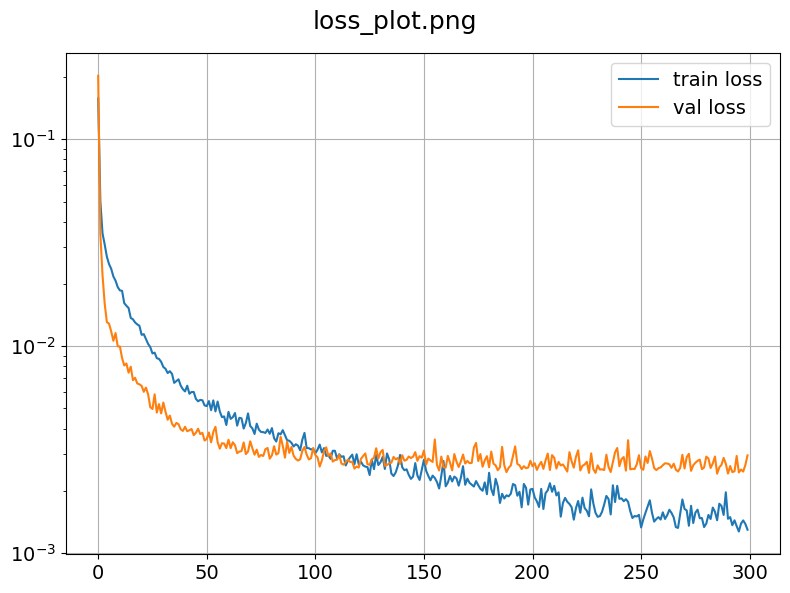

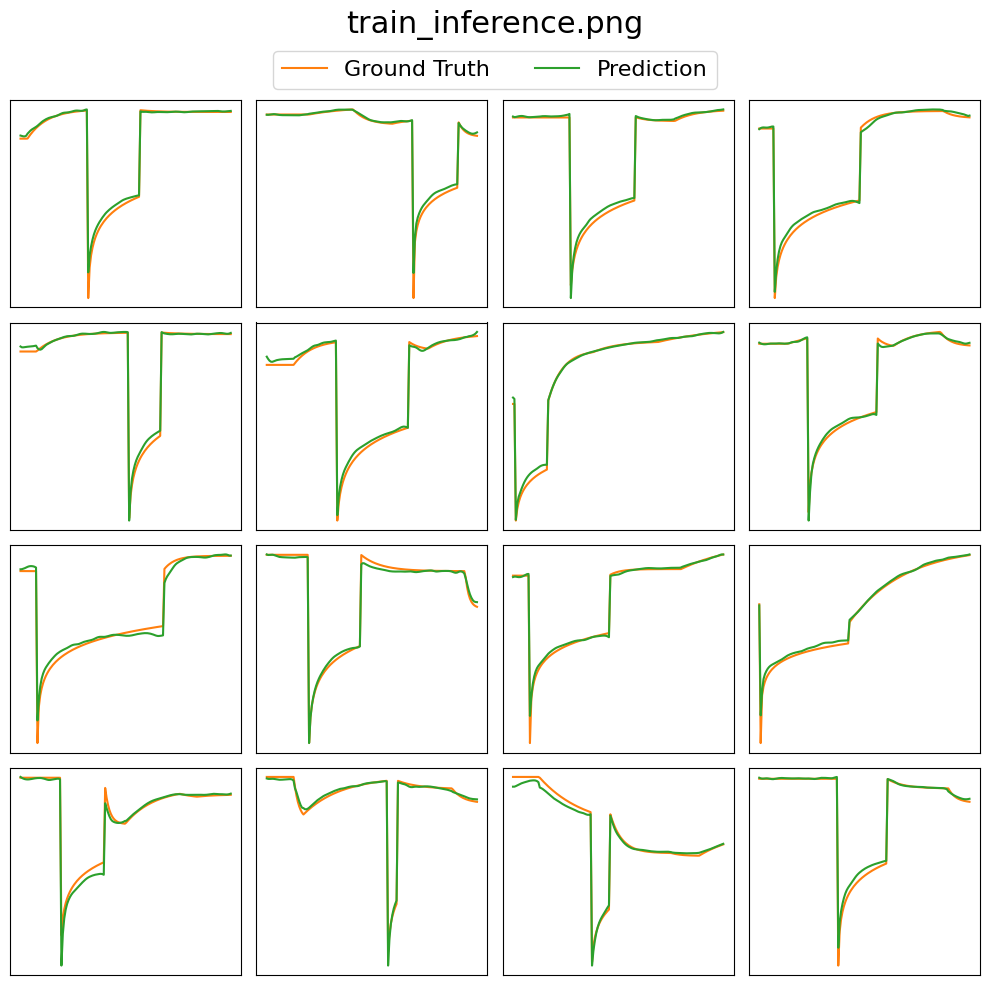

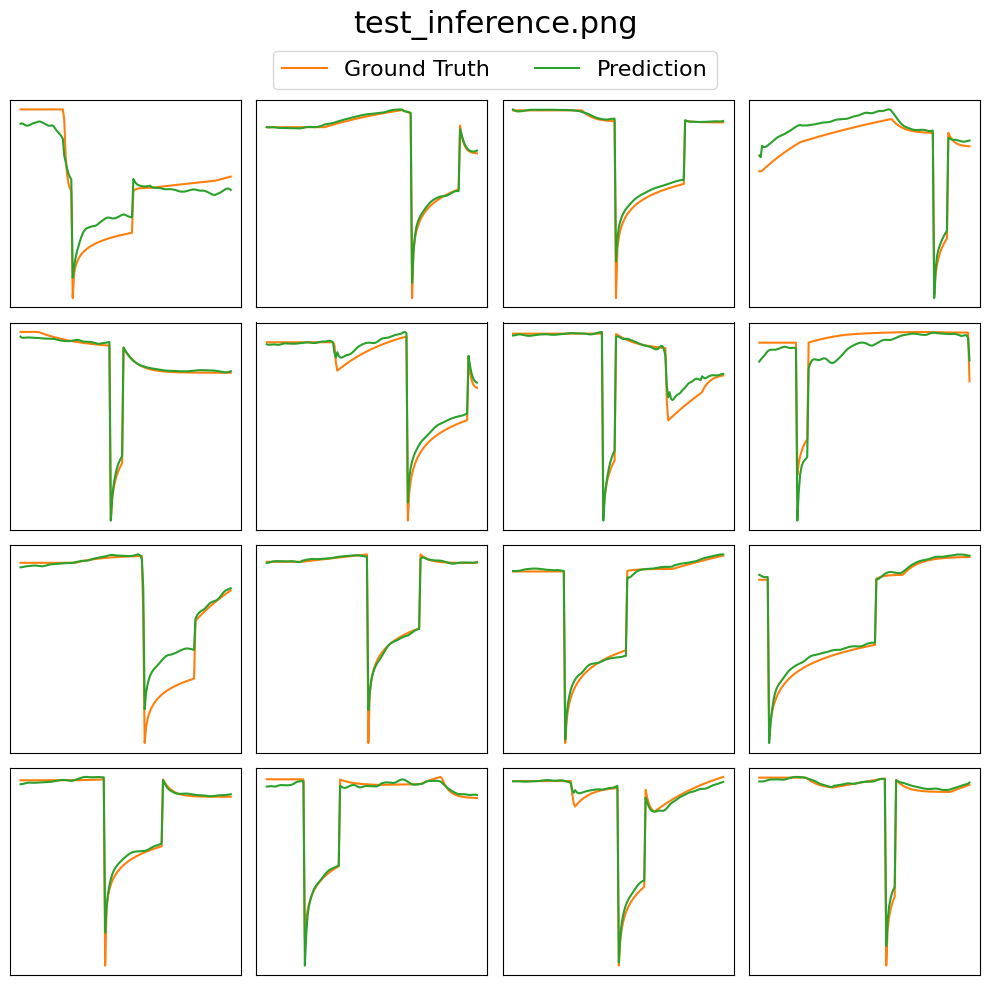

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

check_config(single_config)
data = prepare_data(single_config, device)
model = model_setup(single_config, data, device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

train_model(single_config, model, data, device)
plots(model, data, device)

In [ ]:
import torch
import matplotlib.pyplot as plt


def compute_full_spectrum(x: torch.Tensor) -> torch.Tensor:
    """
    Compute the FFT magnitude spectrum of a tensor of shape (B, C, N).

    Args:
        x: Tensor of shape (batch, channels, spatial_points)

    Returns:
        Tensor of shape (B, C, F) with FFT magnitudes
    """
    x_hat = torch.fft.rfft(x, dim=-1)
    return torch.abs(x_hat)


def plot_block_frequency_response(model,
                                  x: torch.Tensor,
                                  output: torch.Tensor,
                                  sample_idx: int = 0,
                                  logy: bool = True,
                                  normalize: bool = False,
                                  fontsize: float = 12,
                                  title: str = "Frequency response across FNO blocks"):
    """
    Plot the frequency response for each FNO block in a separate subplot.

    For each block, plots the channel-averaged spectrum of:
      - spectral branch
      - bypass branch
      - before activation (after merge + BN)
      - after activation

    Args:
        model: FNO1d model with return_intermediates=True support
        x: Input tensor of shape (B, C, N)
        sample_idx: batch index to inspect
        logy: whether to use log scale on y axis
        normalize: whether to normalize each curve by its DC component
        fontsize: plot fontsize
        title: global figure title

    Returns:
        fig, axes
    """
    was_training = model.training
    model.eval()

    with torch.no_grad():
        _, intermediates = model(x, return_intermediates=True)

    if was_training:
        model.train()

    blocks = intermediates["blocks"]
    n_blocks = len(blocks)

    fig, axes = plt.subplots(
        n_blocks, 1,
        figsize=(6, 3.0 * n_blocks),
        squeeze=False,
        sharex=True
    )
    axes = axes[:, 0]

    for i, block_data in enumerate(blocks):
        ax = axes[i]

        input = block_data["input"]                    # (B, C, N)
        spectral = block_data["spectral"]              # (B, C, N)
        bypass = block_data["bypass"]                  # (B, C, N)
        pre_act = block_data["pre_activation"]         # (B, C, N)
        post_act = block_data["post_activation"]       # (B, C, N)
        
        act = torch.nn.GELU()
        spect_act = act(spectral)             # (B, C, N)

        # FFT magnitude for chosen sample -> (C, F)
        spectral_spec = compute_full_spectrum(spectral)[sample_idx].detach().cpu().mean(dim=0)
        bypass_spec = compute_full_spectrum(bypass)[sample_idx].detach().cpu().mean(dim=0)
        pre_spec = compute_full_spectrum(pre_act)[sample_idx].detach().cpu().mean(dim=0)
        post_spec = compute_full_spectrum(post_act)[sample_idx].detach().cpu().mean(dim=0)
        input_spec = compute_full_spectrum(input)[sample_idx].detach().cpu().mean(dim=0)
        spect_act_spec = compute_full_spectrum(spect_act)[sample_idx].detach().cpu().mean(dim=0)
        output_spec = compute_full_spectrum(output)[sample_idx].detach().cpu().mean(dim=0)

        if normalize:
            spectral_spec = spectral_spec / spectral_spec[0].clamp_min(1e-12)
            bypass_spec = bypass_spec / bypass_spec[0].clamp_min(1e-12)
            pre_spec = pre_spec / pre_spec[0].clamp_min(1e-12)
            post_spec = post_spec / post_spec[0].clamp_min(1e-12)
            input_spec = input_spec / input_spec[0].clamp_min(1e-12)
            spect_act_spec = spect_act_spec / spect_act_spec[0].clamp_min(1e-12)
            output = output_spec/output_spec.clamp_min(1e-12)

        freqs = torch.arange(pre_spec.shape[0]).cpu().numpy()

        ax.plot(
            freqs,
            spectral_spec.numpy(),
            linewidth=2.0,
            linestyle="-",
            label="Post Spectral"
        )
        # ax.plot(
        #     freqs,
        #     bypass_spec.numpy(),
        #     linewidth=2.0,
        #     linestyle="-.",
        #     label="Bypass"
        # )
        # ax.plot(
        #     freqs,
        #     pre_spec.numpy(),
        #     linewidth=1.8,
        #     linestyle="--",
        #     label="Before activation"
        # )
        # ax.plot(
        #     freqs,
        #     post_spec.numpy(),
        #     linewidth=2.0,
        #     linestyle="-",
        #     label="After activation"
        # )

        ax.plot(
            freqs,
            input_spec.numpy(),
            linewidth=1.5,
            linestyle="-",
            label="Input"
        )

        ax.plot(
            freqs,
            spect_act_spec.numpy(),
            linewidth=1.5,
            linestyle="-",
            label="Activation of Post Spectral"
        )
        
        ax.plot(
            freqs,
            output_spec.numpy(),
            linewidth=1.5,
            linestyle="-",
            label="Desired Output"
        )

        ax.set_ylabel("FFT magnitude", fontsize=fontsize)
        ax.set_xlabel("Fourier mode", fontsize=fontsize)
        ax.set_title(f"Block {i+1}", fontsize=fontsize)
        ax.grid(True, alpha=0.3)

        if logy:
            ax.set_yscale("log")

        ax.legend(
            fontsize=fontsize * 0.8,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0
        )

    axes[-1].set_xlabel("Fourier mode", fontsize=fontsize)
    fig.suptitle(title, fontsize=fontsize + 1)
    fig.tight_layout(rect=[0, 0, 0.82, 0.98])

    return fig, axes

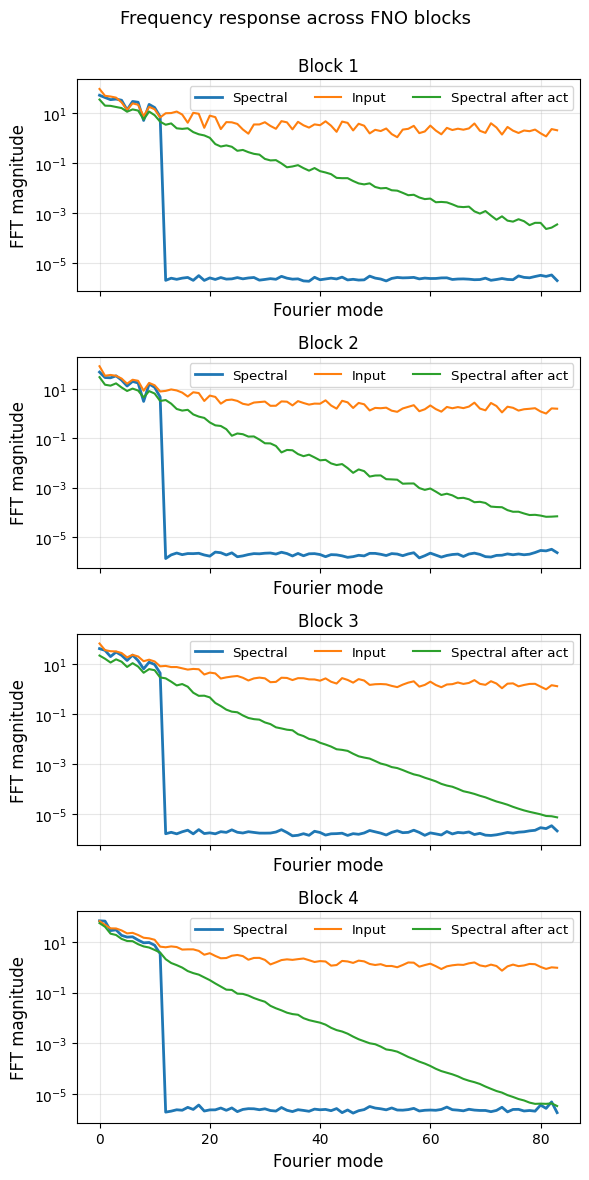

In [ ]:
fig, axes = plot_block_frequency_response(
    model,
    torch.Tensor(data['test_x_norm']),
    torch.Tensor(data['test_y_norm'])
    sample_idx=0,
    logy=True,
    normalize=False,
    fontsize=12
)
plt.show()

In [9]:
import torch
import matplotlib.pyplot as plt


def compute_full_spectrum(x: torch.Tensor) -> torch.Tensor:
    """
    Compute the FFT magnitude spectrum of a tensor of shape (B, C, N).

    Args:
        x: Tensor of shape (batch, channels, spatial_points)

    Returns:
        Tensor of shape (B, C, F) with FFT magnitudes
    """
    x_hat = torch.fft.rfft(x, dim=-1)
    return torch.abs(x_hat)


def _channel_mean_spectrum(x: torch.Tensor,
                           sample_idx: int,
                           normalize: bool = False) -> torch.Tensor:
    """
    Compute channel-averaged FFT magnitude for one sample.

    Args:
        x: Tensor of shape (B, C, N)
        sample_idx: batch index
        normalize: whether to normalize by DC component

    Returns:
        Tensor of shape (F,)
    """
    spec = compute_full_spectrum(x)[sample_idx].detach().cpu().mean(dim=0)

    if normalize:
        spec = spec / spec[0].clamp_min(1e-12)

    return spec


def plot_block_frequency_response(model,
                                  x: torch.Tensor,
                                  y_true: torch.Tensor,
                                  sample_idx: int = 0,
                                  logy: bool = True,
                                  normalize: bool = False,
                                  fontsize: float = 12,
                                  title: str = "Frequency response across FNO blocks"):
    """
    Plot frequency-response evolution through the FNO.

    Subplots:
      1. Input vs lifted input
      2..n+1. One subplot per FNO block showing:
            - spectral branch
            - bypass branch
            - before activation
            - after activation
      last. Before final projection vs after final projection

    Spectra are computed for one sample and averaged across channels.

    Args:
        model: FNO1d model with return_intermediates=True support
        x: Input tensor of shape (B, C, N)
        sample_idx: batch index to inspect
        logy: whether to use log scale on y axis
        normalize: whether to normalize each curve by its DC component
        fontsize: plot fontsize
        title: global figure title

    Returns:
        fig, axes
    """
    was_training = model.training
    model.eval()

    with torch.no_grad():
        _, intermediates = model(x, return_intermediates=True)

    if was_training:
        model.train()

    blocks = intermediates["blocks"]
    n_blocks = len(blocks)

    # 1 subplot for input/lift + n_blocks + 1 subplot for decode/output
    n_subplots = n_blocks + 2

    fig, axes = plt.subplots(
        n_subplots, 1,
        figsize=(10, 3.0 * n_subplots),
        squeeze=False,
        sharex=True
    )
    axes = axes[:, 0]

    # --------------------------------------------------
    # 1) Input / lifted input
    # --------------------------------------------------
    ax = axes[0]

    input_raw = intermediates["input"]               # (B, C_in, N)
    lifted = intermediates["lift"]                   # (B, width, N)

    input_spec = _channel_mean_spectrum(input_raw, sample_idx, normalize)
    lifted_spec = _channel_mean_spectrum(lifted, sample_idx, normalize)

    freqs = torch.arange(max(input_spec.shape[0], lifted_spec.shape[0])).cpu().numpy()

    ax.plot(
        torch.arange(input_spec.shape[0]).cpu().numpy(),
        input_spec.numpy(),
        linewidth=2.0,
        linestyle="-",
        label="Input"
    )
    ax.plot(
        torch.arange(lifted_spec.shape[0]).cpu().numpy(),
        lifted_spec.numpy(),
        linewidth=2.0,
        linestyle="--",
        label="After lifting"
    )

    ax.set_ylabel("FFT magnitude", fontsize=fontsize)
    ax.set_title("Input and lifting", fontsize=fontsize)
    ax.grid(True, alpha=0.3)
    if logy:
        ax.set_yscale("log")
    ax.legend(fontsize=fontsize * 0.8)

    # --------------------------------------------------
    # 2) Block subplots
    # --------------------------------------------------
    for i, block_data in enumerate(blocks):
        ax = axes[i + 1]

        spectral = block_data["spectral"]              # (B, C, N)
        bypass = block_data["bypass"]                  # (B, C, N)
        pre_act = block_data["pre_activation"]         # (B, C, N)
        post_act = block_data["post_activation"]       # (B, C, N)

        spectral_spec = _channel_mean_spectrum(spectral, sample_idx, normalize)
        bypass_spec = _channel_mean_spectrum(bypass, sample_idx, normalize)
        pre_spec = _channel_mean_spectrum(pre_act, sample_idx, normalize)
        post_spec = _channel_mean_spectrum(post_act, sample_idx, normalize)

        freqs = torch.arange(pre_spec.shape[0]).cpu().numpy()

        ax.plot(
            freqs,
            spectral_spec.numpy(),
            linewidth=2.0,
            linestyle="-",
            label="Spectral"
        )
        ax.plot(
            freqs,
            bypass_spec.numpy(),
            linewidth=2.0,
            linestyle="-.",
            label="Bypass"
        )
        ax.plot(
            freqs,
            pre_spec.numpy(),
            linewidth=1.8,
            linestyle="--",
            label="Before activation"
        )
        ax.plot(
            freqs,
            post_spec.numpy(),
            linewidth=2.2,
            linestyle="-",
            label="After activation"
        )

        ax.set_ylabel("FFT magnitude", fontsize=fontsize)
        ax.set_title(f"Block {i+1}", fontsize=fontsize)
        ax.grid(True, alpha=0.3)

        if logy:
            ax.set_yscale("log")

        ax.legend(fontsize=fontsize * 0.8, ncol=2)

    # --------------------------------------------------
    # 3) Before decode / final output
    # --------------------------------------------------
    ax = axes[-1]

    before_decode = intermediates["before_decode"]    # (B, width, N)
    final_output = intermediates["output"]            # (B, C_out, N)

    before_decode_spec = _channel_mean_spectrum(before_decode, sample_idx, normalize)
    final_output_spec = _channel_mean_spectrum(final_output, sample_idx, normalize)
    y_true_spec = _channel_mean_spectrum(y_true, sample_idx, normalize)

    ax.plot(
        torch.arange(before_decode_spec.shape[0]).cpu().numpy(),
        before_decode_spec.numpy(),
        linewidth=2.0,
        linestyle="-",
        label="Before final projection"
    )
    ax.plot(
        torch.arange(final_output_spec.shape[0]).cpu().numpy(),
        final_output_spec.numpy(),
        linewidth=2.0,
        linestyle="--",
        label="After final projection"
    )

    ax.plot(
        torch.arange(y_true_spec.shape[0]).cpu().numpy(),
        y_true_spec.numpy(),
        linewidth=2.5,
        linestyle=":",
        label="Ground truth"
    )

    ax.set_ylabel("FFT magnitude", fontsize=fontsize)
    ax.set_title("Output projection", fontsize=fontsize)
    ax.grid(True, alpha=0.3)
    if logy:
        ax.set_yscale("log")
    ax.legend(fontsize=fontsize * 0.8)

    axes[-1].set_xlabel("Fourier mode", fontsize=fontsize)
    fig.suptitle(title, fontsize=fontsize + 1)
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    return fig, axes

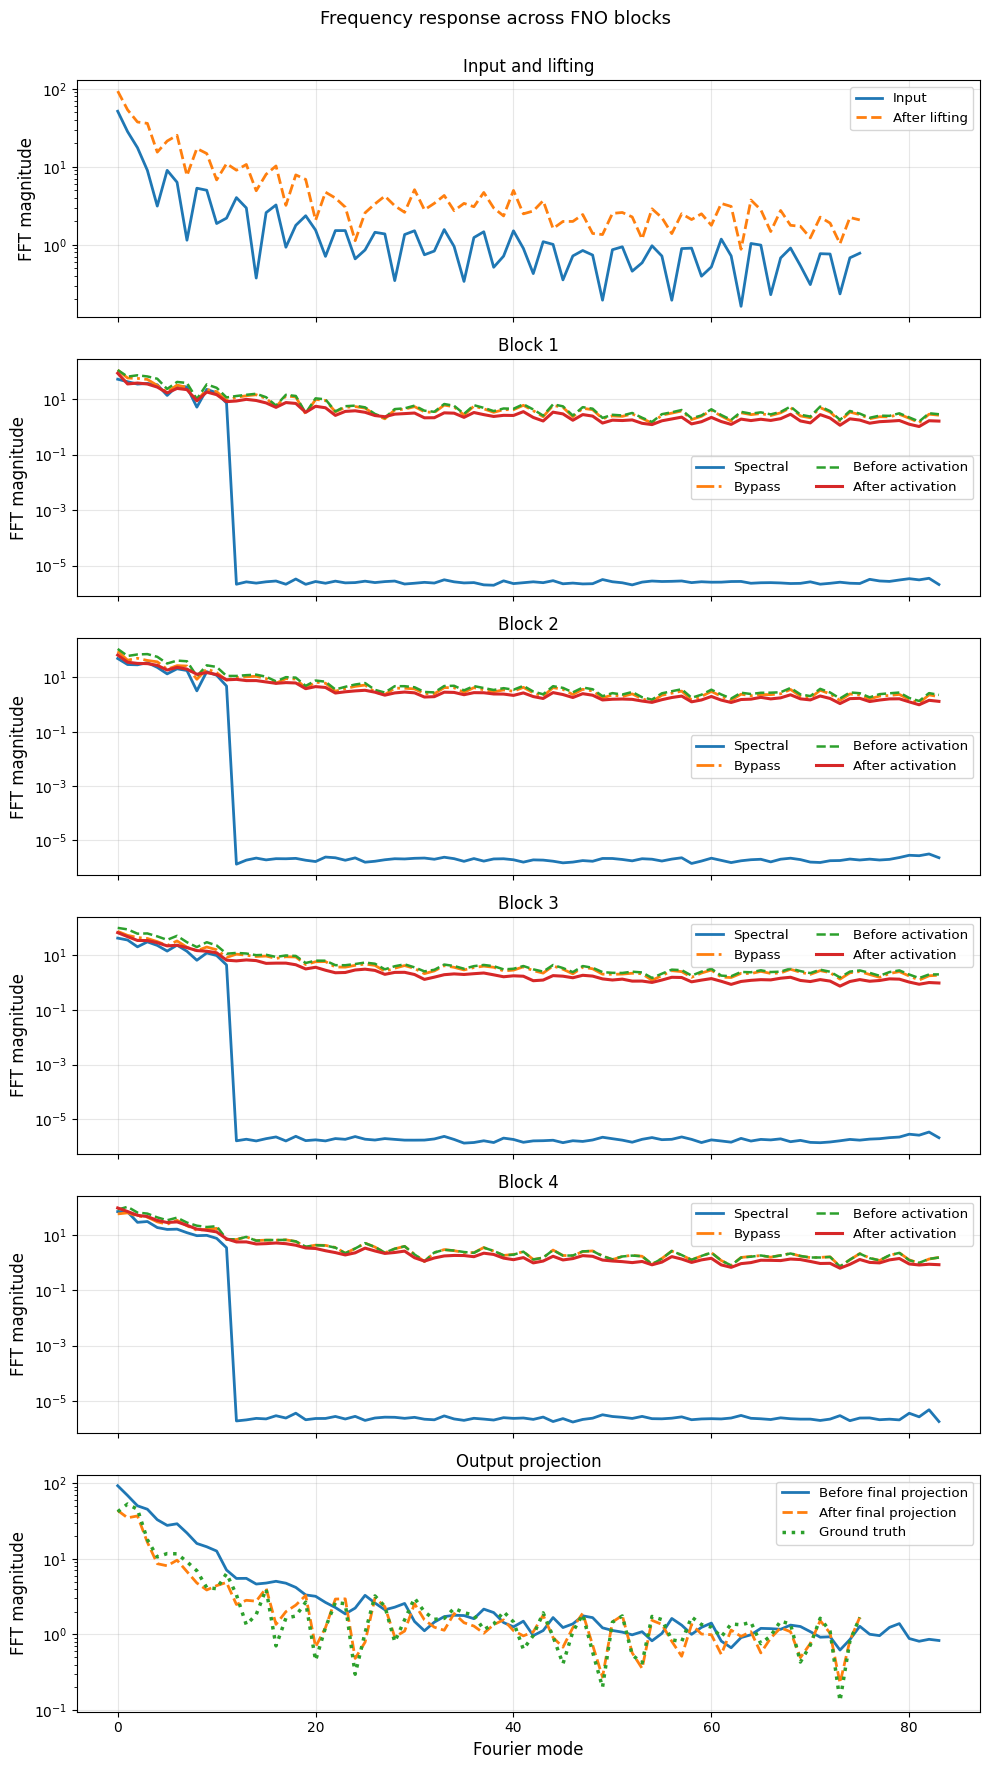

In [10]:
fig, axes = plot_block_frequency_response(
    model,
    torch.Tensor(data['test_x_norm']),
    torch.Tensor(data['test_y_norm']),
    sample_idx=0,
    logy=True,
    normalize=False,
    fontsize=12
)
plt.show()

In [11]:
import torch
import matplotlib.pyplot as plt


def compute_full_spectrum(x: torch.Tensor) -> torch.Tensor:
    """
    Compute the FFT magnitude spectrum of a tensor of shape (B, C, N).

    Args:
        x: Tensor of shape (batch, channels, spatial_points)

    Returns:
        Tensor of shape (B, C, F) with FFT magnitudes
    """
    x_hat = torch.fft.rfft(x, dim=-1)
    return torch.abs(x_hat)


def _single_channel_spectrum(x: torch.Tensor,
                             sample_idx: int,
                             channel_idx: int,
                             normalize: bool = False) -> torch.Tensor:
    """
    Compute FFT magnitude spectrum for one sample and one channel.
    """
    spec = compute_full_spectrum(x)[sample_idx, channel_idx].detach().cpu()

    if normalize:
        spec = spec / spec[0].clamp_min(1e-12)

    return spec


def _mean_channel_spectrum(x: torch.Tensor,
                           sample_idx: int,
                           normalize: bool = False) -> torch.Tensor:
    """
    Compute FFT magnitude spectrum averaged across channels for one sample.
    """
    spec = compute_full_spectrum(x)[sample_idx].detach().cpu().mean(dim=0)

    if normalize:
        spec = spec / spec[0].clamp_min(1e-12)

    return spec


def plot_block_frequency_response_subset(model,
                                         x: torch.Tensor,
                                         y_true: torch.Tensor | None = None,
                                         sample_idx: int = 0,
                                         channel_indices: list[int] = [0, 1, 2],
                                         logy: bool = True,
                                         normalize: bool = False,
                                         fontsize: float = 12,
                                         title: str = "Frequency response across FNO blocks"):
    """
    Plot FFT spectra in a grid:
      - rows    = stages
      - columns = mean + selected channels

    Rows:
      1. Input
      2. Lifting
      3..n+2. One row per FNO block
      n+3. Before final projection
      n+4. Final output

    Columns:
      1. Mean across channels
      2..end. Selected channels from channel_indices

    Args:
        model: FNO1d model with return_intermediates=True support
        x: Input tensor of shape (B, C, N)
        y_true: Ground-truth output tensor of shape (B, C_out, N), optional
        sample_idx: batch index to inspect
        channel_indices: latent/output channels to plot
        logy: whether to use log scale on y axis
        normalize: whether to normalize each spectrum by its DC component
        fontsize: plot fontsize
        title: global figure title

    Returns:
        fig, axes
    """
    was_training = model.training
    model.eval()

    with torch.no_grad():
        _, intermediates = model(x, return_intermediates=True)

    if was_training:
        model.train()

    blocks = intermediates["blocks"]
    n_blocks = len(blocks)
    n_rows = n_blocks + 4
    n_cols = len(channel_indices) + 1

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.2 * n_cols, 2.8 * n_rows),
        squeeze=False,
        sharex=True
    )

    # -----------------------------
    # 1) Input row
    # -----------------------------
    input_raw = intermediates["input"]

    for col in range(n_cols):
        ax = axes[0, col]
        is_mean_col = (col == 0)

        if is_mean_col:
            input_spec = _mean_channel_spectrum(input_raw, sample_idx, normalize)
            freqs = torch.arange(input_spec.shape[0]).cpu().numpy()

            ax.plot(freqs, input_spec.numpy(), linewidth=2.0, label="Input")
            ax.set_title("Input — mean", fontsize=fontsize)
            ax.legend(fontsize=fontsize * 0.75)
        else:
            ch = channel_indices[col - 1]
            if ch < input_raw.shape[1]:
                input_spec = _single_channel_spectrum(input_raw, sample_idx, ch, normalize)
                freqs = torch.arange(input_spec.shape[0]).cpu().numpy()

                ax.plot(freqs, input_spec.numpy(), linewidth=2.0, label="Input")
                ax.legend(fontsize=fontsize * 0.75)

            ax.set_title(f"Input — ch {ch}", fontsize=fontsize)

        ax.grid(True, alpha=0.3)
        if logy:
            ax.set_yscale("log")
        if col == 0:
            ax.set_ylabel("FFT magnitude", fontsize=fontsize)

    # -----------------------------
    # 2) Lifting row
    # -----------------------------
    lifted = intermediates["lift"]

    for col in range(n_cols):
        ax = axes[1, col]
        is_mean_col = (col == 0)

        if is_mean_col:
            lifted_spec = _mean_channel_spectrum(lifted, sample_idx, normalize)
            freqs = torch.arange(lifted_spec.shape[0]).cpu().numpy()

            ax.plot(freqs, lifted_spec.numpy(), linewidth=2.0, label="After lifting")
            ax.set_title("Lifting — mean", fontsize=fontsize)
            ax.legend(fontsize=fontsize * 0.75)
        else:
            ch = channel_indices[col - 1]
            if ch < lifted.shape[1]:
                lifted_spec = _single_channel_spectrum(lifted, sample_idx, ch, normalize)
                freqs = torch.arange(lifted_spec.shape[0]).cpu().numpy()

                ax.plot(freqs, lifted_spec.numpy(), linewidth=2.0, label="After lifting")
                ax.legend(fontsize=fontsize * 0.75)

            ax.set_title(f"Lifting — ch {ch}", fontsize=fontsize)

        ax.grid(True, alpha=0.3)
        if logy:
            ax.set_yscale("log")
        if col == 0:
            ax.set_ylabel("FFT magnitude", fontsize=fontsize)

    # -----------------------------
    # 3) Block rows
    # -----------------------------

    activation = torch.nn.GELU()
    for i, block_data in enumerate(blocks):
        spectral = block_data["spectral"]
        bypass = block_data["bypass"]
        pre_act = block_data["pre_activation"]
        post_act = block_data["post_activation"]

        for col in range(n_cols):
            ax = axes[i + 2, col]
            is_mean_col = (col == 0)

            if is_mean_col:
                spectral_spec = _mean_channel_spectrum(spectral, sample_idx, normalize)
                bypass_spec = _mean_channel_spectrum(bypass, sample_idx, normalize)
                pre_spec = _mean_channel_spectrum(pre_act, sample_idx, normalize)
                post_spec = _mean_channel_spectrum(post_act, sample_idx, normalize)
                spect_act_spec = _mean_channel_spectrum(activation(spectral), sample_idx, normalize)

                freqs = torch.arange(spectral_spec.shape[0]).cpu().numpy()

                ax.plot(freqs, spectral_spec.numpy(), linewidth=1.6, label="Spectral")
                ax.plot(freqs, bypass_spec.numpy(),   linewidth=1.6, label="Bypass")
                ax.plot(freqs, pre_spec.numpy(),      linewidth=1.6, label="Pre-act")
                ax.plot(freqs, post_spec.numpy(),     linewidth=2.0, label="Post-act")
                ax.plot(freqs, spect_act_spec.numpy(), linewidth=1.5, linestyle=":", label="Spectral after act")

                ax.set_title(f"Block {i+1} — mean", fontsize=fontsize)
                ax.legend(fontsize=fontsize * 0.65, ncol=2)
            else:
                ch = channel_indices[col - 1]
                if ch < spectral.shape[1]:
                    spectral_spec = _single_channel_spectrum(spectral, sample_idx, ch, normalize)
                    bypass_spec = _single_channel_spectrum(bypass, sample_idx, ch, normalize)
                    pre_spec = _single_channel_spectrum(pre_act, sample_idx, ch, normalize)
                    post_spec = _single_channel_spectrum(post_act, sample_idx, ch, normalize)
                    spectral_act_spec = _single_channel_spectrum(activation(spectral), sample_idx, ch, normalize)

                    freqs = torch.arange(spectral_spec.shape[0]).cpu().numpy()

                    ax.plot(freqs, spectral_spec.numpy(), linewidth=1.6, label="Spectral")
                    ax.plot(freqs, bypass_spec.numpy(),   linewidth=1.6, label="Bypass")
                    ax.plot(freqs, pre_spec.numpy(),      linewidth=1.6, label="Pre-act")
                    ax.plot(freqs, post_spec.numpy(),     linewidth=2.0, label="Post-act")
                    ax.plot(freqs, spectral_act_spec.numpy(), linewidth=1.5, linestyle=":", label="Spectral after act")

                    ax.legend(fontsize=fontsize * 0.65, ncol=2)

                ax.set_title(f"Block {i+1} — ch {ch}", fontsize=fontsize)

            ax.grid(True, alpha=0.3)
            if logy:
                ax.set_yscale("log")
            if col == 0:
                ax.set_ylabel("FFT magnitude", fontsize=fontsize)

    # -----------------------------
    # 4) Before final projection row
    # -----------------------------
    before_decode = intermediates["before_decode"]
    row_idx = n_blocks + 2

    for col in range(n_cols):
        ax = axes[row_idx, col]
        is_mean_col = (col == 0)

        if is_mean_col:
            spec = _mean_channel_spectrum(before_decode, sample_idx, normalize)
            freqs = torch.arange(spec.shape[0]).cpu().numpy()

            ax.plot(freqs, spec.numpy(), linestyle="-", linewidth=2.0, label="Before proj")
            ax.set_title("Before projection — mean", fontsize=fontsize)
            ax.legend(fontsize=fontsize * 0.7)
        else:
            ch = channel_indices[col - 1]
            if ch < before_decode.shape[1]:
                spec = _single_channel_spectrum(before_decode, sample_idx, ch, normalize)
                freqs = torch.arange(spec.shape[0]).cpu().numpy()

                ax.plot(freqs, spec.numpy(), linestyle="-", linewidth=2.0, label="Before proj")
                ax.legend(fontsize=fontsize * 0.7)

            ax.set_title(f"Before projection — ch {ch}", fontsize=fontsize)

        ax.grid(True, alpha=0.3)
        if logy:
            ax.set_yscale("log")
        if col == 0:
            ax.set_ylabel("FFT magnitude", fontsize=fontsize)

    # -----------------------------
    # 5) Final output row
    # -----------------------------
    final_output = intermediates["output"]
    row_idx = n_blocks + 3

    if y_true is not None:
        if y_true.shape[1] != final_output.shape[1] and y_true.ndim == 3 and y_true.shape[2] == final_output.shape[1]:
            y_true = y_true.permute(0, 2, 1)

    for col in range(n_cols):
        ax = axes[row_idx, col]
        is_mean_col = (col == 0)

        if is_mean_col:
            if y_true is not None:
                spec = _mean_channel_spectrum(y_true, sample_idx, normalize)
                freqs = torch.arange(spec.shape[0]).cpu().numpy()
                ax.plot(freqs, spec.numpy(), linewidth=2.4, color="black", label="Ground truth")

            spec = _mean_channel_spectrum(final_output, sample_idx, normalize)
            freqs = torch.arange(spec.shape[0]).cpu().numpy()
            ax.plot(freqs, spec.numpy(), linestyle=":", linewidth=2.0, label="Output")

            ax.set_title("Output — mean", fontsize=fontsize)
            ax.legend(fontsize=fontsize * 0.7)
        else:
            ch = channel_indices[col - 1]

            if y_true is not None and ch < y_true.shape[1]:
                spec = _single_channel_spectrum(y_true, sample_idx, ch, normalize)
                freqs = torch.arange(spec.shape[0]).cpu().numpy()
                ax.plot(freqs, spec.numpy(), linewidth=2.4, color="black", label="Ground truth")

            if ch < final_output.shape[1]:
                spec = _single_channel_spectrum(final_output, sample_idx, ch, normalize)
                freqs = torch.arange(spec.shape[0]).cpu().numpy()
                ax.plot(freqs, spec.numpy(), linestyle=":", linewidth=2.0, label="Output")

            ax.set_title(f"Output — ch {ch}", fontsize=fontsize)
            ax.legend(fontsize=fontsize * 0.7)

        ax.grid(True, alpha=0.3)
        if logy:
            ax.set_yscale("log")
        if col == 0:
            ax.set_ylabel("FFT magnitude", fontsize=fontsize)

    # Bottom x-labels
    for col in range(n_cols):
        axes[-1, col].set_xlabel("Fourier mode", fontsize=fontsize)

    fig.suptitle(title, fontsize=fontsize + 1)
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    return fig, axes

C:\Users\mathi\AppData\Local\Temp\ipykernel_33212\2223975010.py:307: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=fontsize * 0.7)


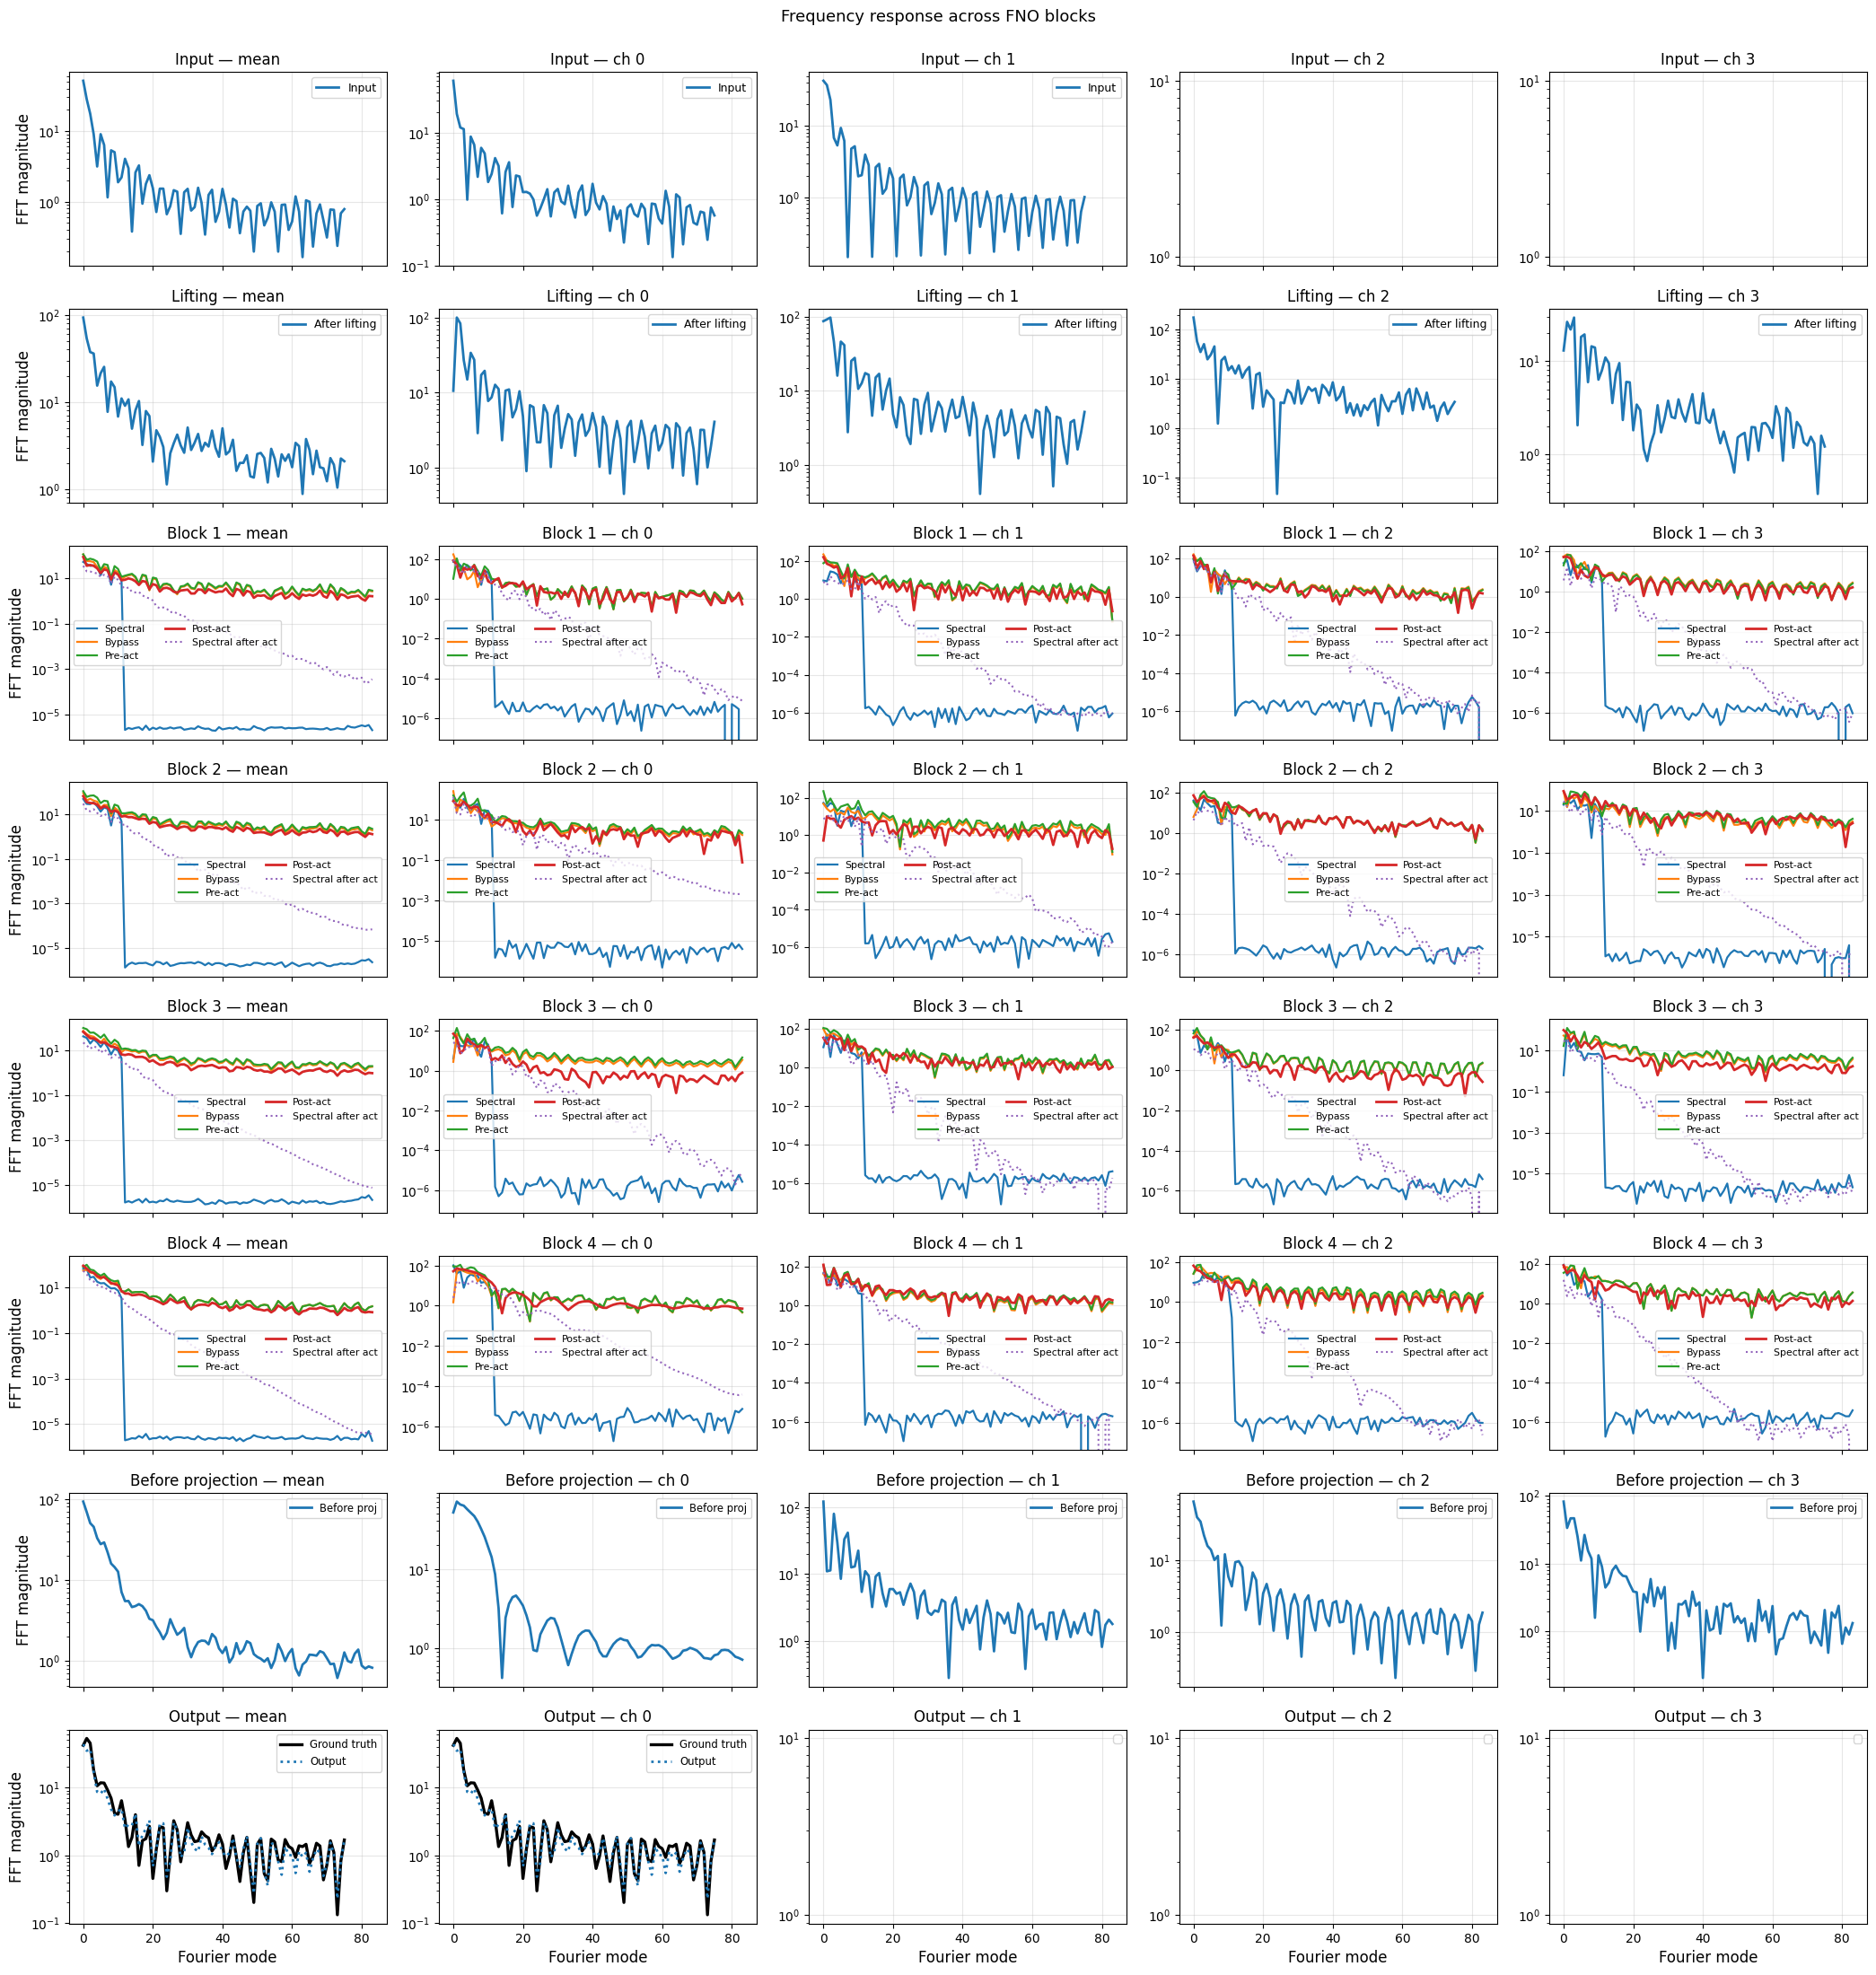

In [12]:
fig, axes = plot_block_frequency_response_subset(
    model,
    torch.Tensor(data['test_x_norm']),
    torch.Tensor(data['test_y_norm']),
    channel_indices=[0, 1, 2, 3],
    sample_idx=0,
    logy=True,
    normalize=False,
    fontsize=12
)
plt.show()